In [1]:
# !pip install catboost

# !pip install optuna

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize

import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier
import catboost as cb
from catboost import CatBoostClassifier, Pool
import optuna
from optuna.samplers import TPESampler

import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
df_model = pd.read_csv('/content/drive/MyDrive/df_model.csv')
df_model.head(5)

,dong_cd,biz_cd,yq_cd,target_class,prev_sls_amt_tot_log,prev_fl_pop_tot_log,prev_wk_pop_tot_log,prev_rs_pop_tot_log,prev_apt_avg_price_log,prev_is_univ,...,prev_fl_pop_tot_log_STD2,prev_fl_pop_tot_log_MA4,prev_fl_pop_tot_log_STD4,prev_fl_pop_tot_log_QoQ,prev_store_density_MA2,prev_store_density_STD2,prev_store_density_MA4,prev_store_density_STD4,prev_store_density_QoQ,prev_cluster_id
0,11110515,CS100001,20192,1,21.386510,15.115219,8.776013,9.476390,19.310098,1.0,...,0.000000,15.115219,0.000000,0.000000,0.000031,0.000000e+00,0.000031,0.000000e+00,0.000000,1.0
1,11110515,CS100001,20193,1,21.470838,15.156251,8.776013,9.475086,19.310098,1.0,...,0.029014,15.135735,0.029014,0.002715,0.000031,2.753068e-07,0.000031,2.753068e-07,-0.009462,1.0
2,11110515,CS100001,20194,2,21.438412,15.151398,8.776013,9.475086,19.310098,1.0,...,0.003431,15.140956,0.022421,-0.000320,0.000030,8.259204e-07,0.000030,8.104813e-07,-0.028658,1.0
3,11110515,CS100001,20201,0,21.692543,15.196653,8.776013,9.458606,19.310098,1.0,...,0.032000,15.154880,0.033327,0.002987,0.000030,8.259204e-07,0.000031,6.743612e-07,0.029503,1.0
4,11110515,CS100001,20202,1,21.446476,15.099848,8.776013,9.458606,19.310098,1.0,...,0.068451,15.151038,0.039701,-0.006370,0.000030,1.101227e-06,0.000030,8.026503e-07,-0.038210,1.0


In [4]:
print(list(df_model.columns))

['dong_cd', 'biz_cd', 'yq_cd', 'target_class', 'prev_sls_amt_tot_log', 'prev_fl_pop_tot_log', 'prev_wk_pop_tot_log', 'prev_rs_pop_tot_log', 'prev_apt_avg_price_log', 'prev_is_univ', 'prev_is_arpt', 'prev_edu_cnt', 'prev_traffic_score', 'prev_sls_per_store', 'prev_store_density', 'prev_ATV', 'prev_conversion_rate', 'prev_franchise_ratio', 'prev_rs_pop_ratio', 'prev_wk_pop_ratio', 'prev_exp_per_hh', 'prev_exp_food_ratio', 'prev_sls_wkdy_ratio', 'prev_sls_wknd_ratio', 'prev_sls_lunch_ratio', 'prev_sls_afternoon_ratio', 'prev_sls_evening_ratio', 'prev_sls_night_ratio', 'prev_sls_2030s_ratio', 'prev_sls_3050s_ratio', 'prev_sls_60s_ratio', 'prev_sls_amt_tot_log_MA2', 'prev_sls_amt_tot_log_STD2', 'prev_sls_amt_tot_log_MA4', 'prev_sls_amt_tot_log_STD4', 'prev_sls_amt_tot_log_QoQ', 'prev_sls_per_store_MA2', 'prev_sls_per_store_STD2', 'prev_sls_per_store_MA4', 'prev_sls_per_store_STD4', 'prev_sls_per_store_QoQ', 'prev_ATV_MA2', 'prev_ATV_STD2', 'prev_ATV_MA4', 'prev_ATV_STD4', 'prev_ATV_QoQ', 'p

## 모델 학습

STEP 1. OOT 분할 및 다중 모델 베이스라인 평가

In [5]:
# OOT 데이터 분할 및 타겟/식별자 분리
# 시간 기준 분할: 가장 최근 1개 분기를 Test, 그 직전 1개 분기를 Val, 나머지를 Train으로 설정
unique_quarters = sorted(df_model['yq_cd'].unique())
test_quarter = unique_quarters[-1]
val_quarter = unique_quarters[-2]

train_df = df_model[df_model['yq_cd'] < val_quarter]
val_df = df_model[df_model['yq_cd'] == val_quarter]
test_df = df_model[df_model['yq_cd'] == test_quarter]

drop_cols = ['yq_cd', 'dong_cd', 'biz_cd', 'target_class']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['target_class'].astype(int)

X_val = val_df.drop(columns=drop_cols)
y_val = val_df['target_class'].astype(int)

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['target_class'].astype(int)

print(f"=== 데이터 분할 완료 ===")
print(f"Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")

=== 데이터 분할 완료 ===
Train(357365), Val(17048), Test(16937)


In [6]:
import time
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.metrics import f1_score, accuracy_score

# 범주형 변수 지정
cat_cols = ['prev_is_univ', 'prev_is_arpt', 'prev_cluster_id']
for col in cat_cols:
    X_train[col] = X_train[col].astype(int).astype('category')
    X_val[col] = X_val[col].astype(int).astype('category')
    X_test[col] = X_test[col].astype(int).astype('category')

# GPU 지원 모델 세팅
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        tree_method='hist',
        device='cuda',
        random_state=42
    ),
    'LightGBM': lgb.LGBMClassifier(
        objective='multiclass',
        device='cpu',
        random_state=42,
        verbose=-1
    ),
    'CatBoost': cb.CatBoostClassifier(
        loss_function='MultiClass',
        task_type='GPU',
        random_state=42,
        verbose=0
    )
}

baseline_results = {}

print("=== Baseline 평가 시작 ===")
for name, model in models.items():
    start_time = time.time()

    # 모델별 맞춤형 학습 (Early Stopping 및 Cat Feature 적용)
    if name == 'XGBoost':
        # XGBoost는 카테고리 변수 지원을 위해 enable_categorical=True 옵션 필요
        model.set_params(enable_categorical=True)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    elif name == 'LightGBM':
        # LightGBM의 early_stopping은 callbacks 리스트로 전달 (최신 API 기준)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  categorical_feature=cat_cols, callbacks=[lgb.early_stopping(50, verbose=False)])

    elif name == 'CatBoost':
        model.fit(X_train, y_train, eval_set=(X_val, y_val),
                  cat_features=cat_cols, early_stopping_rounds=50)

    # 검증셋(OOT) 예측 및 성능 평가 (Macro F1)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)

    baseline_results[name] = {'F1': f1, 'Accuracy': acc}
    elapsed_time = time.time() - start_time

    print(f"[{name}] Macro F1-Score: {f1:.4f} | Accuracy: {acc:.4f} (학습 시간: {elapsed_time:.1f}초)")

=== Baseline 평가 시작 ===
[XGBoost] Macro F1-Score: 0.5863 | Accuracy: 0.7045 (학습 시간: 2.8초)
[LightGBM] Macro F1-Score: 0.5799 | Accuracy: 0.7000 (학습 시간: 7.5초)
[CatBoost] Macro F1-Score: 0.5825 | Accuracy: 0.7020 (학습 시간: 6.8초)


레포트 함수 선언

In [7]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc, accuracy_score

def generate_model_report(y_true, preds, probs, model_name="Model"):
    print(f"\n========================================================")
    print(f"[{model_name} 성능 평가 리포트]")
    print(f"========================================================")

    # 1. Macro F1
    macro_f1 = f1_score(y_true, preds, average='macro')
    acc = accuracy_score(y_true, preds)

    print(f" Accuracy (정확도) : {acc:.4f}")
    print(f" Macro F1 Score    : {macro_f1:.4f}")

    # 2. ROC-AUC (OvR)
    roc_auc = roc_auc_score(y_true, probs, multi_class='ovr', average='macro')
    print(f"\n[Multi-class ROC-AUC (OvR) : {roc_auc:.4f}]")

    # 3. Classification Report
    print(f"\n[{model_name} 분류 리포트]")
    print(classification_report(y_true, preds, target_names=["위축(0)", "유지(1)", "성장(2)"]))

    # 4. Confusion Matrix
    print("\n[Confusion Matrix (혼동 행렬)]")
    conf_mat = confusion_matrix(y_true, preds)
    display(pd.DataFrame(conf_mat,
                         index=["실제:위축(0)", "실제:유지(1)", "실제:성장(2)"],
                         columns=["예측:위축(0)", "예측:유지(1)", "예측:성장(2)"]))

    print("\n")

    # 5. ROC Curve 시각화
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False

    n_classes = 3
    class_names = ['위축(0)', '유지(1)', '성장(2)']
    colors = ['blue', 'green', 'red']

    plt.figure(figsize=(6, 4))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true == i, probs[:, i])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'{class_names[i]} (AUC = {class_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=8)
    plt.ylabel('True Positive Rate (TPR)', fontsize=8)
    plt.title(f'{model_name} 다중 클래스 ROC 곡선 (OvR)', fontsize=12)
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()

[Step 2] Optuna 기반 LightGBM 정밀 튜닝

In [13]:
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

def objective_lgb(trial):
    params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'random_state': 42,
        'class_weight': {0: 2.0, 1: 1.0, 2: 1.0},
        'n_jobs': -1,   # gpu 대신 cpu 사용
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 64),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 40, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }

    model = LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    preds = model.predict(X_val)
    return f1_score(y_val, preds, average='macro')

# Optuna 실행 (maximize로 설정)
sampler = TPESampler(seed=42)

study_lgb = optuna.create_study(direction='maximize', sampler=sampler)
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=False)

print("\n[LightGBM 최적 파라미터로 최종 학습]")
print(study_lgb.best_params)

# 튜닝 후 전체 Train으로 재학습
best_lgb_params = study_lgb.best_params
best_lgb_params.update({
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'random_state': 42,
    'class_weight': {0: 2.0, 1: 1.0, 2: 1.0},
    'n_jobs': -1,
    'verbose': -1
})

[I 2026-08-16 13:13:58,131] A new study created in memory with name: no-name-b05fb517-7e05-46c7-bb3d-24ae7e07748c
[I 2026-08-16 13:14:19,949] Trial 0 finished with value: 0.5955826935635309 and parameters: {'n_estimators': 500, 'learning_rate': 0.08927180304353628, 'num_leaves': 51, 'max_depth': 5, 'min_child_samples': 57, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 0.2537815508265665}. Best is trial 0 with value: 0.5955826935635309.
[I 2026-08-16 13:15:32,909] Trial 1 finished with value: 0.5916237788902772 and parameters: {'n_estimators': 767, 'learning_rate': 0.010485387725194618, 'num_leaves': 63, 'max_depth': 7, 'min_child_samples': 63, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 0.016480446427978974, 'reg_lambda': 0.12561043700013558}. Best is trial 0 with value: 0.5955826935635309.
[I 2026-08-16 13:15:52,628] Trial 2 finished with value: 0.5838517643900558 and par


[LightGBM 최적 파라미터로 최종 학습]
{'n_estimators': 971, 'learning_rate': 0.05230381056679128, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 135, 'subsample': 0.9404052868155786, 'colsample_bytree': 0.7267340845030492, 'reg_alpha': 0.3854099985114089, 'reg_lambda': 1.1119049507413399}


In [14]:
# 튜닝 결과 및 파라미터 출력
print(f"[LightGBM 튜닝 완료]")
print(f"Best CV Macro F1: {study_lgb.best_value:.4f}")
print("Best Parameters:")
for key, value in best_lgb_params.items():
    print(f"  - {key}: {value}")

# 최적 파라미터로 단 한 번만 학습 (학습 곡선 기록용 eval_set 포함)
final_lgb = LGBMClassifier(**best_lgb_params)
final_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

[LightGBM 튜닝 완료]
Best CV Macro F1: 0.5991
Best Parameters:
  - n_estimators: 971
  - learning_rate: 0.05230381056679128
  - num_leaves: 54
  - max_depth: 6
  - min_child_samples: 135
  - subsample: 0.9404052868155786
  - colsample_bytree: 0.7267340845030492
  - reg_alpha: 0.3854099985114089
  - reg_lambda: 1.1119049507413399
  - objective: multiclass
  - metric: multi_logloss
  - random_state: 42
  - class_weight: {0: 2.0, 1: 1.0, 2: 1.0}
  - n_jobs: -1
  - verbose: -1


LGBMClassifier(class_weight={0: 2.0, 1: 1.0, 2: 1.0},
               colsample_bytree=0.7267340845030492,
               learning_rate=0.05230381056679128, max_depth=6,
               metric='multi_logloss', min_child_samples=135, n_estimators=971,
               n_jobs=-1, num_leaves=54, objective='multiclass',
               random_state=42, reg_alpha=0.3854099985114089,
               reg_lambda=1.1119049507413399, subsample=0.9404052868155786,
               verbose=-1)

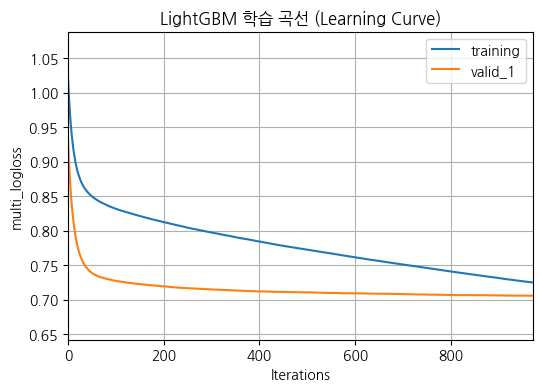

In [15]:
# LightGBM 학습 곡선
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

lgb.plot_metric(final_lgb, metric='multi_logloss', figsize=(6, 4))
plt.title('LightGBM 학습 곡선 (Learning Curve)')
plt.show()


[LightGBM 단일 모델 (Test) 성능 평가 리포트]
 Accuracy (정확도) : 0.6884
 Macro F1 Score    : 0.6071

[Multi-class ROC-AUC (OvR) : 0.8109]

[LightGBM 단일 모델 (Test) 분류 리포트]
              precision    recall  f1-score   support

       위축(0)       0.46      0.51      0.48      2774
       유지(1)       0.78      0.81      0.79     10312
       성장(2)       0.59      0.50      0.54      3851

    accuracy                           0.69     16937
   macro avg       0.61      0.61      0.61     16937
weighted avg       0.69      0.69      0.69     16937


[Confusion Matrix (혼동 행렬)]


,예측:위축(0),예측:유지(1),예측:성장(2)
실제:위축(0),1406,1000,368
실제:유지(1),1027,8316,969
실제:성장(2),617,1297,1937


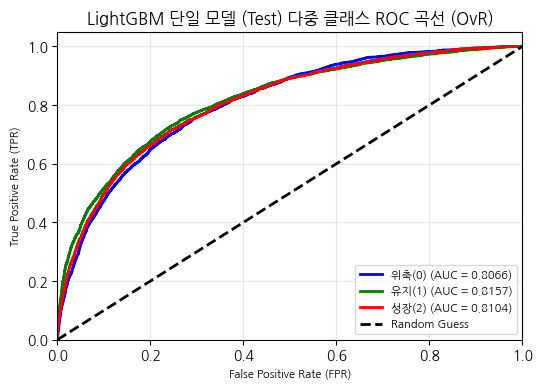

In [11]:
# Test 셋으로 LightGBM 개별 모델 평가
lgb_test_preds = final_lgb.predict(X_test)
lgb_test_probs = final_lgb.predict_proba(X_test)
generate_model_report(y_test, lgb_test_preds, lgb_test_probs, model_name="LightGBM 단일 모델 (Test)")

[Step 3] Optuna 기반 CatBoost 정밀 튜닝(보류)

In [ ]:
# import optuna
# import catboost as cb
# from catboost import CatBoostClassifier
# from sklearn.metrics import f1_score

# print("\n=== CatBoost Optuna 튜닝 시작 ===")

# def objective_cb(trial):
#     params = {
#         'loss_function': 'MultiClass',
#         'task_type': 'GPU',
#         'auto_class_weights': 'Balanced',
#         'random_state': 42,
#         'verbose': 0,
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'depth': trial.suggest_int('depth', 4, 8),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
#         'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True)
#     }

#     # iterations(트리 개수)를 1000으로 넉넉하게 두고 early_stopping 적용
#     model = CatBoostClassifier(**params, iterations=1000)

#     # eval_set으로 검증하며 조기 종료 수행
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         cat_features=cat_cols,          # CatBoost 전용 범주형 변수 지정 파라미터
#         early_stopping_rounds=50,       # 50번 동안 성능 향상이 없으면 멈춤
#         verbose=False
#     )

#     preds = model.predict(X_val)
#     return f1_score(y_val, preds, average='macro')

# # Optuna 실행 (maximize로 설정)
# study_cb = optuna.create_study(direction='maximize')
# study_cb.optimize(objective_cb, n_trials=30, show_progress_bar=False)

# print("\n[CatBoost 최적 파라미터로 최종 학습]")
# print(study_cb.best_params)

# # 튜닝 후 전체 Train으로 재학습
# # 찾은 최적의 파라미터에 기본 고정 파라미터 다시 병합
# best_cb_params = study_cb.best_params
# best_cb_params.update({
#     'loss_function': 'MultiClass', 'task_type': 'GPU',
#     'auto_class_weights': 'Balanced', 'random_state': 42, 'verbose': 0
# })

In [ ]:
# # 튜닝 결과 및 파라미터 출력
# print(f"[CatBoost 튜닝 완료]")
# print(f"Best CV Macro F1: {study_cb.best_value:.4f}")
# print("Best Parameters:")
# for key, value in best_cb_params.items():
#     print(f"  - {key}: {value}")

# final_cb = CatBoostClassifier(**best_cb_params, iterations=1000)
# final_cb.fit(
#     X_train, y_train,
#     eval_set=[(X_val, y_val)], cat_features=cat_cols,
#     early_stopping_rounds=50, verbose=False
# )

In [ ]:
# # CatBoost 학습 곡선
# evals_result = final_cb.get_evals_result()
# plt.figure(figsize=(6, 4))
# plt.plot(evals_result['learn']['MultiClass'], label='Train')
# plt.plot(evals_result['validation']['MultiClass'], label='Validation')
# plt.title('CatBoost 학습 곡선')
# plt.legend()
# plt.show()

In [ ]:
# # Test 셋으로 CatBoost 개별 모델 평가
# cb_test_preds = final_cb.predict(X_test)
# cb_test_probs = final_cb.predict_proba(X_test)
# generate_model_report(y_test, cb_test_preds, cb_test_probs, model_name="CatBoost 단일 모델 (Test)")

[Step 4] 앙상블 가중치 산출 및 과적합 점검(보류)

In [ ]:
# # 1. 검증셋(Val) 확률 추출 (이미 학습된 final_lgb, final_cb 재활용 - 효율성 증대)
# val_probs_lgb = final_lgb.predict_proba(X_val)
# val_probs_cb = final_cb.predict_proba(X_val)

# # 2. 최적 가중치 탐색 함수 (Grid Search)
# best_f1 = 0
# best_weight = 0

# # LightGBM 가중치(w)를 0.00부터 1.00까지 0.01 단위로 테스트
# # CatBoost 가중치는 자연스럽게 (1 - w)가 됨
# for w in np.linspace(0, 1, 101):
#     blended_prob = (w * val_probs_lgb) + ((1 - w) * val_probs_cb)
#     blended_preds = np.argmax(blended_prob, axis=1)

#     current_f1 = f1_score(y_val, blended_preds, average='macro')

#     if current_f1 > best_f1:
#         best_f1 = current_f1
#         best_weight = w

# opt_weights = [best_weight, 1 - best_weight]

# print(f"✅ 산출된 최적 가중치 -> LightGBM : CatBoost = {opt_weights[0]:.2f} : {opt_weights[1]:.2f}")
# print(f" - 해당 가중치에서의 Val Macro F1 : {best_f1:.4f}")

# # 3. 과적합 모니터링을 위한 임시 F1 Score 산출
# train_probs_lgb = final_lgb.predict_proba(X_train)
# train_probs_cb = final_cb.predict_proba(X_train)

# train_prob = (opt_weights[0] * train_probs_lgb) + (opt_weights[1] * train_probs_cb)
# train_preds = np.argmax(train_prob, axis=1)
# train_f1 = f1_score(y_train, train_preds, average='macro')

# val_prob = (opt_weights[0] * val_probs_lgb) + (opt_weights[1] * val_probs_cb)
# val_preds = np.argmax(val_prob, axis=1)
# val_f1 = f1_score(y_val, val_preds, average='macro')

# print(f" - Train 앙상블 Macro F1 : {train_f1:.4f}")
# print(f" - Val 앙상블 Macro F1   : {val_f1:.4f}")

[Step 5] 전체 데이터 재학습(Retrain) 및 최종 평가 (OOT)(보류)

In [ ]:
# # 1. 데이터 통합 (Train + Val)
# X_train_full = pd.concat([X_train, X_val], axis=0)
# y_train_full = pd.concat([y_train, y_val], axis=0)

# # 2. [핵심] 조기 종료로 찾은 '최적의 트리 개수' 추출
# best_iter_lgb = final_lgb.best_iteration_
# best_iter_cb = final_cb.get_best_iteration() + 1
# print(f"적용될 최적 트리 개수 - LightGBM: {best_iter_lgb}개, CatBoost: {best_iter_cb}개")

# # 3. 재학습용 모델 객체 생성 (고정된 트리 개수 할당)
# retrained_lgb = LGBMClassifier(**best_lgb_params, n_estimators=best_iter_lgb)
# retrained_cb = CatBoostClassifier(**best_cb_params, iterations=best_iter_cb)

# # 4. 전체 데이터(Train+Val)로 최종 학습 (eval_set 없음, 조기종료 없음)
# print("전체 데이터 재학습 진행 중...")
# retrained_lgb.fit(X_train_full, y_train_full, categorical_feature=cat_cols)
# retrained_cb.fit(X_train_full, y_train_full, cat_features=cat_cols, verbose=False)

# # 5. 한 번도 보지 못한 Test 데이터 예측
# test_probs_lgb = retrained_lgb.predict_proba(X_test)
# test_probs_cb = retrained_cb.predict_proba(X_test)

# # 6. 산출했던 최적 가중치 적용
# final_prob = (opt_weights[0] * test_probs_lgb) + (opt_weights[1] * test_probs_cb)
# final_preds = np.argmax(final_prob, axis=1)

# # 7. 앞서 만들어둔 리포트 함수로 최종 결과 출력
# generate_model_report(y_test, final_preds, final_prob, model_name="가중치 최적화 최종 앙상블 (Test OOT)")

Confusion Matrix

=== 1. 최종 앙상블 모델 Confusion Matrix ===


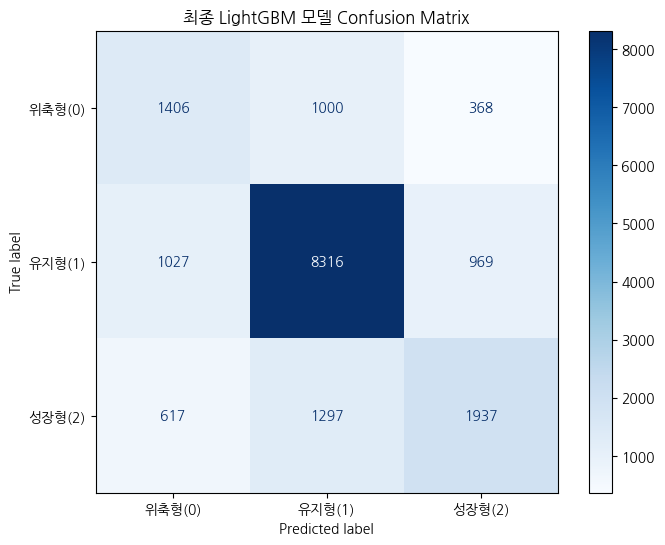

In [16]:
plt.rcParams['axes.unicode_minus'] = False

print("=== 1. 최종 앙상블 모델 Confusion Matrix ===")
cm = confusion_matrix(y_test, lgb_test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["위축형(0)", "유지형(1)", "성장형(2)"])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('최종 LightGBM 모델 Confusion Matrix', fontsize=12)
plt.show()

Feature Importance

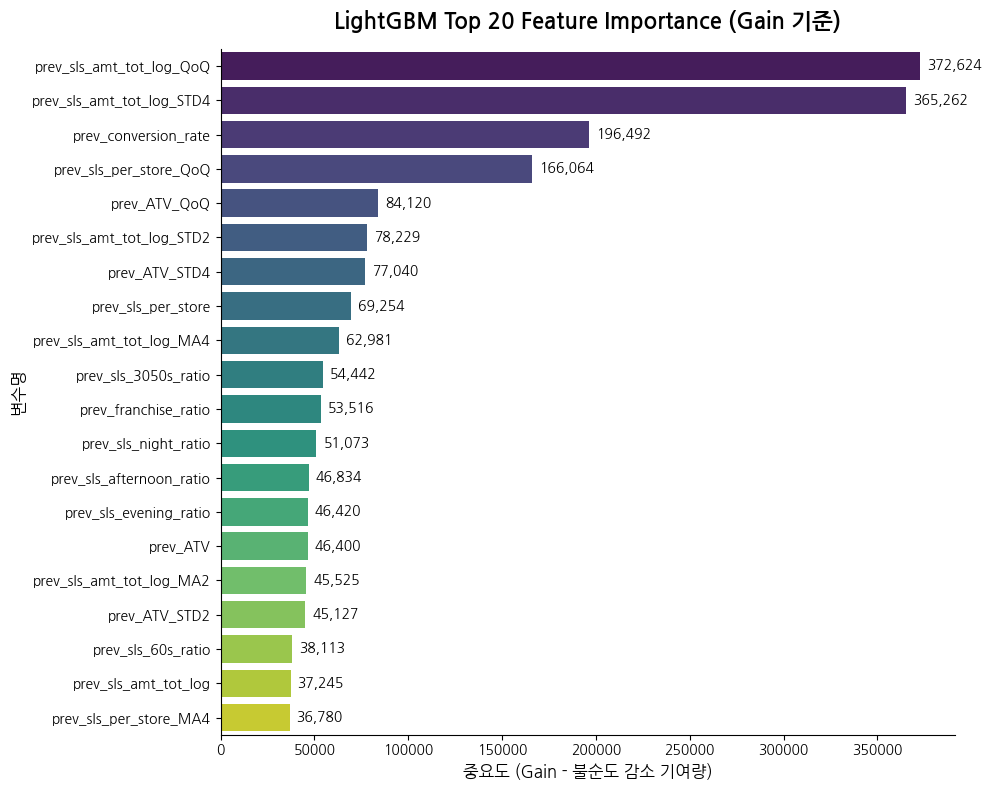

In [18]:
# 1. Split이 아닌 'Gain' 기준으로 변수 중요도 추출 (LGBM 객체 내부 booster 접근)
gain_importance = final_lgb.booster_.feature_importance(importance_type='gain')
lgb_gain = pd.Series(gain_importance, index=X_train.columns)

# 2. 상위 20개 추출
lgb_top20_gain = lgb_gain.sort_values(ascending=False)[:20]

# 3. 시각화 (레이아웃 및 수치 표시)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=lgb_top20_gain.values, y=lgb_top20_gain.index, palette='viridis', ax=ax)

# 축 및 타이틀 설정
ax.set_title('LightGBM Top 20 Feature Importance (Gain 기준)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('중요도 (Gain - 불순도 감소 기여량)', fontsize=12)
ax.set_ylabel('변수명', fontsize=12)

# 막대 끝에 실제 수치 텍스트 추가 (가독성을 위해 정수로 포맷팅)
for i, v in enumerate(lgb_top20_gain.values):
    ax.text(v + (max(lgb_top20_gain.values) * 0.01), i, f'{v:,.0f}',
            color='black', va='center', fontsize=10)

# 테두리 정리 (우측, 상단 선 제거)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

SHAP 분석

=== SHAP 분석: 성장 요인 ===


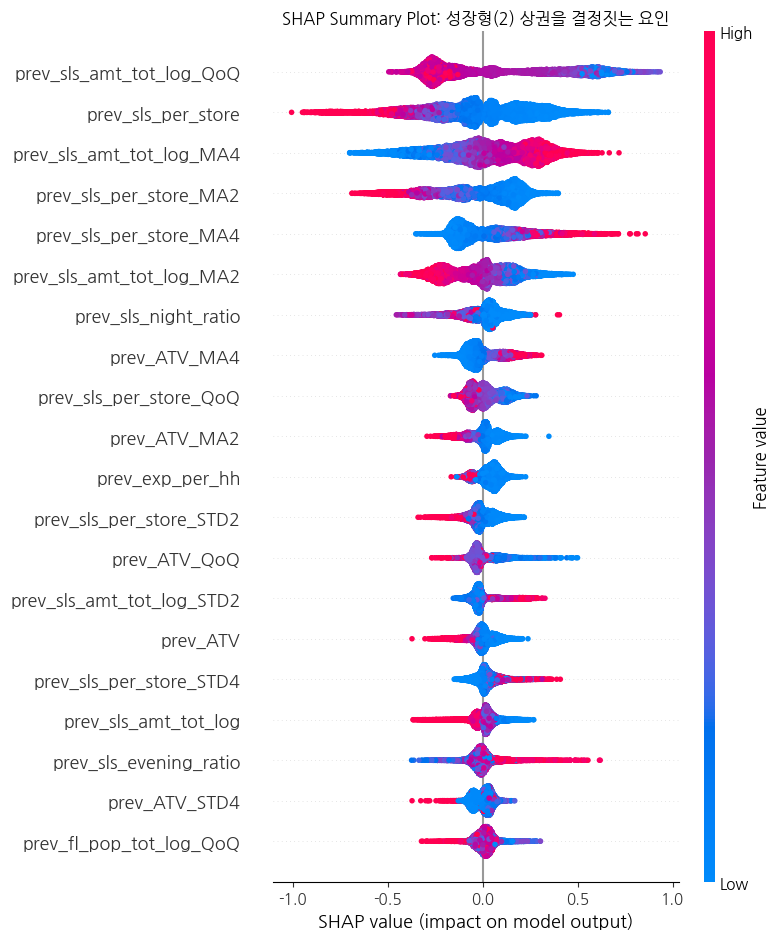

In [21]:
import shap
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("=== SHAP 분석: 성장 요인 ===")

# 1. SHAP TreeExplainer 초기화 (튜닝된 LightGBM 모델 사용)
explainer = shap.TreeExplainer(final_lgb)

# # 2. 계산 속도를 위해 Test 셋에서 무작위로 2000개 샘플 추출
# X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test)

# 4. 다중 분류 3개 클래스(0:위축, 1:유지, 2:성장) 중 "2(성장형)"에 대한 SHAP 값 추출
# shap 버전이 최신일 경우 shap_values[:, :, 2] 형태로 인덱싱. (구버전은 shap_values[2])
try:
    shap_values_target = shap_values[:, :, 2]
except IndexError:
    shap_values_target = shap_values[2]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(8, 4))
plt.title("SHAP Summary Plot: 성장형(2) 상권을 결정짓는 요인", fontsize=12)

# 빨간 점(Feature 값이 높을 때)과 파란 점(Feature 값이 낮을 때)이
# 오른쪽(성장 확률 증가)과 왼쪽(성장 확률 감소) 중 어디로 향하는지 보여주는 그래프
shap.summary_plot(shap_values_target, X_test, show=False)

plt.tight_layout()
plt.show()

=== SHAP 분석: 위축 요인 ===


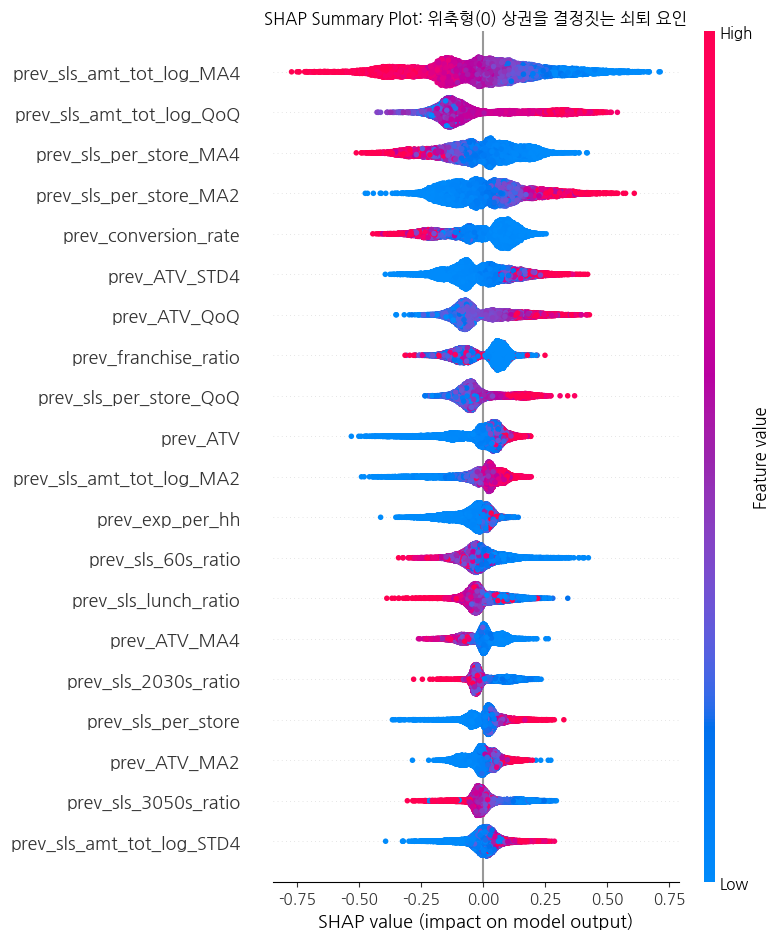

In [22]:
print("=== SHAP 분석: 위축 요인 ===")

# 1. SHAP TreeExplainer 초기화
explainer = shap.TreeExplainer(final_lgb)

# 2. Test 셋에서 무작위로 샘플 추출
# X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test)

# 4. 다중 분류 3개 클래스 중 "0(위축형)"에 대한 SHAP 값 추출
try:
    shap_values_shrink = shap_values[:, :, 0]
except IndexError:
    shap_values_shrink = shap_values[0]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(8, 4))
plt.title("SHAP Summary Plot: 위축형(0) 상권을 결정짓는 쇠퇴 요인", fontsize=12)

shap.summary_plot(shap_values_shrink, X_test, show=False)

plt.tight_layout()
plt.show()


Threshold 탐색

1. SHAP 의존성 플롯 (Dependence Plot) 그리기

<Figure size 700x500 with 0 Axes>

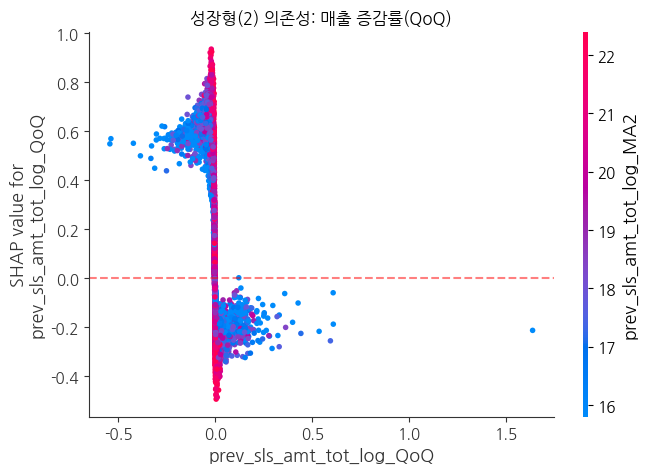

<Figure size 700x500 with 0 Axes>

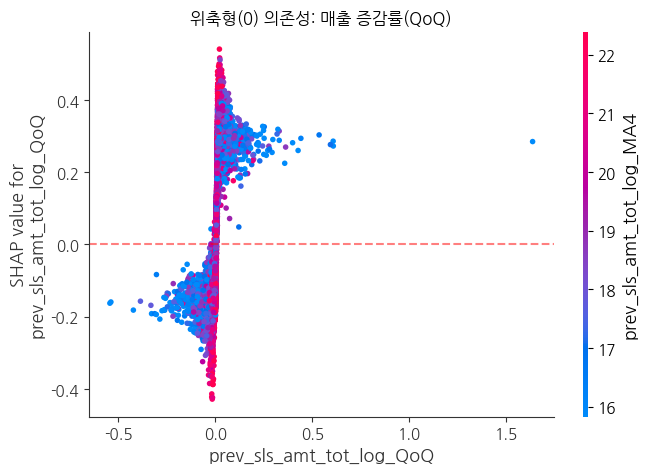

In [24]:
# [1] 매출 증감률 (prev_sls_amt_tot_log_QoQ) 분석
# 1-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_sls_amt_tot_log_QoQ', shap_values_target, X_test,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 매출 증감률(QoQ)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 1-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_sls_amt_tot_log_QoQ', shap_values_shrink, X_test,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 매출 증감률(QoQ)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

<Figure size 700x500 with 0 Axes>

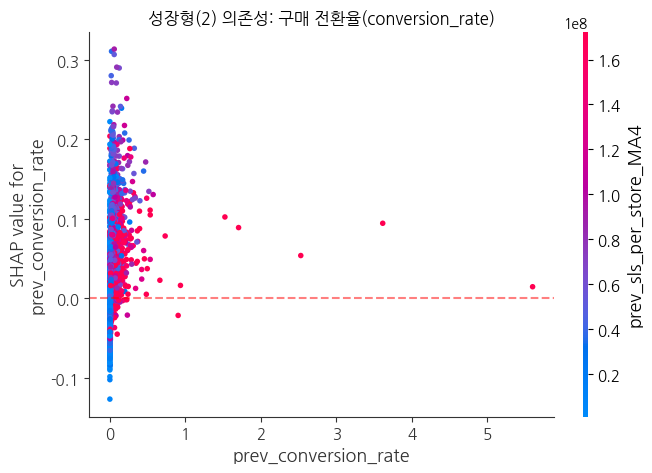

<Figure size 700x500 with 0 Axes>

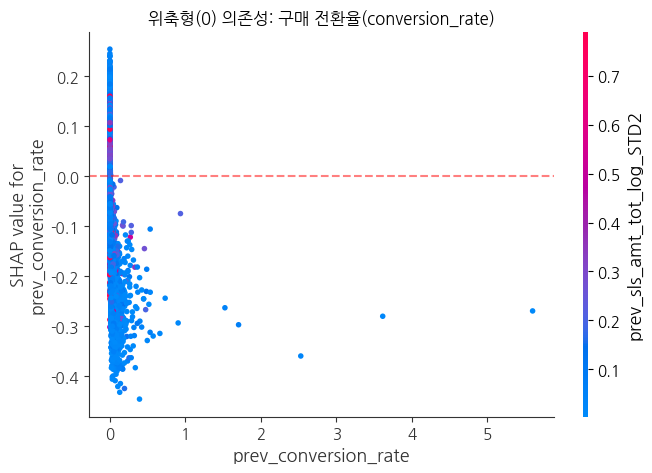

In [26]:
# [2] 구매 전환율 (prev_conversion_rate) 분석

# 2-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_conversion_rate', shap_values_target, X_test,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 구매 전환율(conversion rate)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 2-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_conversion_rate', shap_values_shrink, X_test,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 구매 전환율(conversion rate)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

<Figure size 700x500 with 0 Axes>

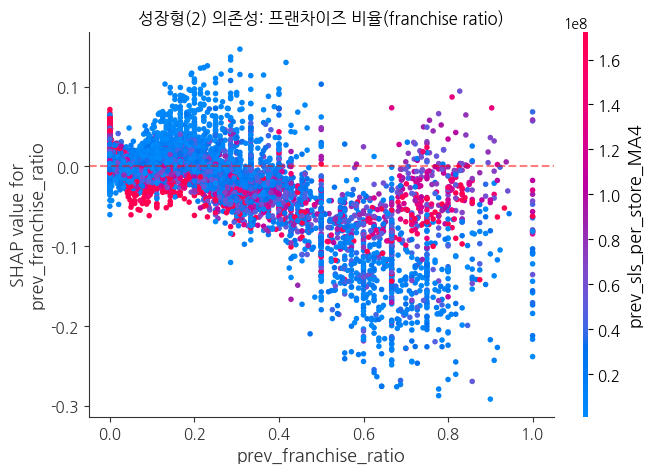

<Figure size 700x500 with 0 Axes>

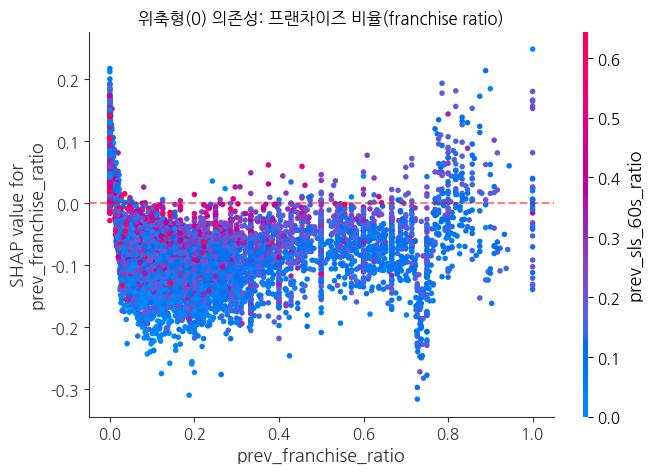

In [30]:
# [3] 프랜차이즈 비율 (prev_franchise_ratio) 분석

# 3-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_franchise_ratio', shap_values_target, X_test,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 프랜차이즈 비율(franchise ratio)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 3-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_franchise_ratio', shap_values_shrink, X_test,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 프랜차이즈 비율(franchise ratio)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

<Figure size 700x500 with 0 Axes>

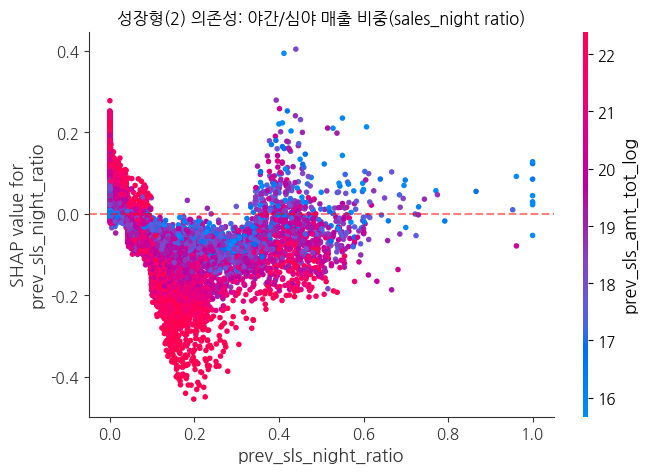

<Figure size 700x500 with 0 Axes>

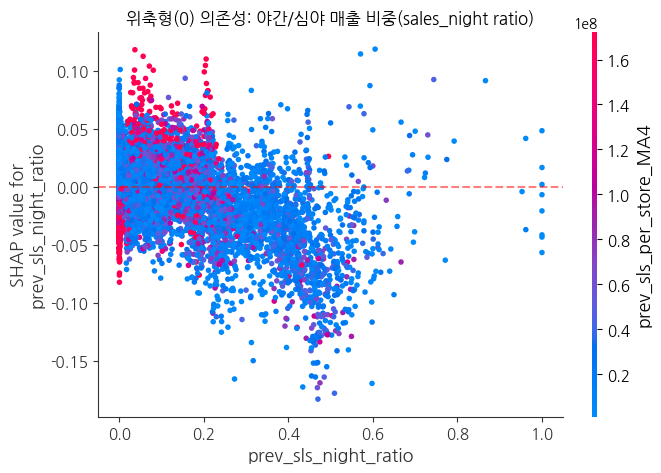

In [31]:
# [4] 야간/심야 매출 비중 (prev_sls_night_ratio) 분석

# 4-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_sls_night_ratio', shap_values_target, X_test,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 야간/심야 매출 비중(sales_night ratio)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 4-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_sls_night_ratio', shap_values_shrink, X_test,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 야간/심야 매출 비중(sales_night ratio)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

<Figure size 700x500 with 0 Axes>

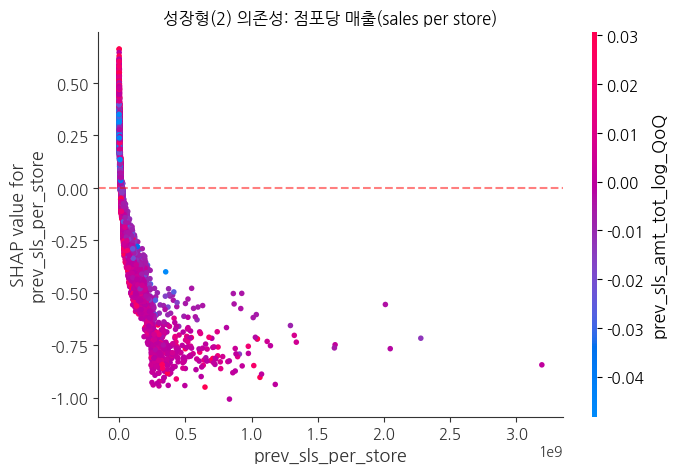

<Figure size 700x500 with 0 Axes>

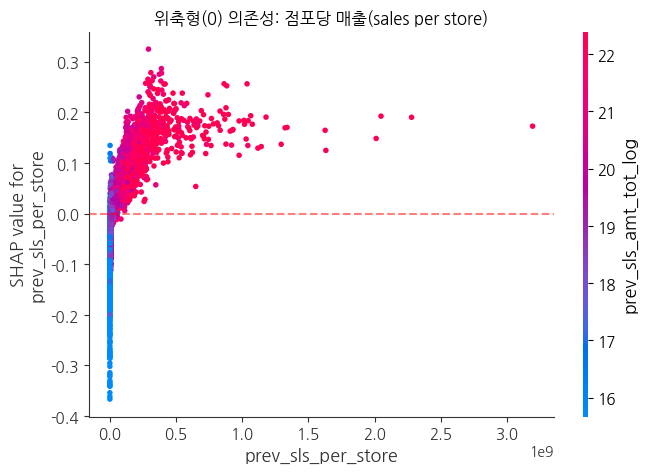

In [33]:
# [5] 점포당 매출 (prev_sls_per_store) 분석
# 5-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_sls_per_store', shap_values_target, X_test,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 점포당 매출(sales per store)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 5-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_sls_per_store', shap_values_shrink, X_test,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 점포당 매출(sales per store)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

<Figure size 700x500 with 0 Axes>

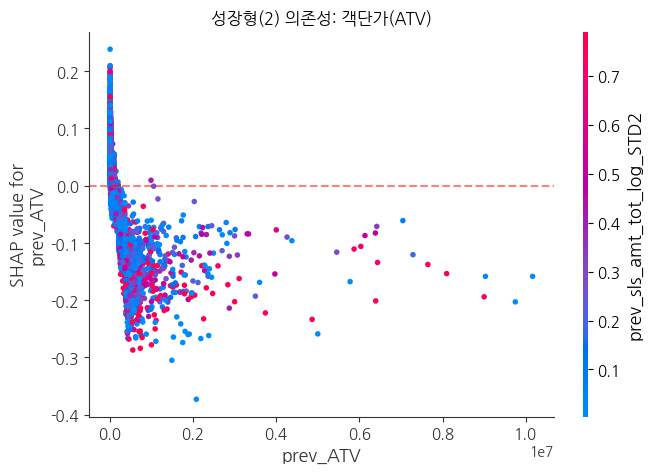

<Figure size 700x500 with 0 Axes>

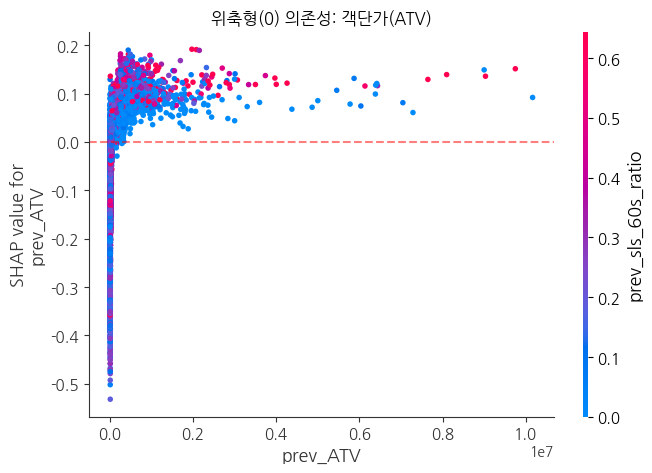

In [34]:
# [5] 객단가 (prev_ATV) 분석
# 5-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_ATV', shap_values_target, X_test,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 객단가(ATV)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 5-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_ATV', shap_values_shrink, X_test,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 객단가(ATV)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

2. 직관적인 통계치 확인 (EDA 방식)

In [35]:
print("=== 클래스별 실제 객단가(ATV) 기초 통계 ===")
atv_stats = test_df.groupby('target_class')['prev_ATV'].agg(['mean', 'median', 'min', 'max']).round(0)
atv_stats.index = ['위축형(0)', '유지형(1)', '성장형(2)']
print(atv_stats)

=== 클래스별 실제 객단가(ATV) 기초 통계 ===
            mean   median    min         max
위축형(0)  212083.0  81595.0  500.0   8098420.0
유지형(1)   95209.0  32437.0   99.0  10165294.0
성장형(2)  109878.0  40379.0  101.0   9032258.0


군집별 정답률(성능) 분석

In [38]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# 1. 결과 데이터프레임 생성 (실제값, 예측값, 군집ID 포함)
cluster_analysis_df = pd.DataFrame({
    'actual': y_test,
    'pred': lgb_test_preds,
    'cluster_id': test_df['prev_cluster_id'].values
})

# 2. 군집별 성능 저장할 리스트
cluster_perf = []

for cluster in sorted(cluster_analysis_df['cluster_id'].unique()):
    subset = cluster_analysis_df[cluster_analysis_df['cluster_id'] == cluster]

    f1 = f1_score(subset['actual'], subset['pred'], average='macro')
    acc = accuracy_score(subset['actual'], subset['pred'])

    # '위축형(0)'에 대한 Recall(재현율) 계산
    shrink_actual = subset[subset['actual'] == 0]
    shrink_recall = (shrink_actual['actual'] == shrink_actual['pred']).mean()

    # '성장형(2)'에 대한 Recall(재현율) 계산
    growth_actual = subset[subset['actual'] == 2]
    growth_recall = (growth_actual['actual'] == growth_actual['pred']).mean()

    cluster_perf.append({
        'Cluster': cluster,
        'Sample_Size': len(subset),
        'Accuracy': acc,
        'Macro_F1': f1,
        'Shrink_Recall': shrink_recall,
        'Growth_Recall': growth_recall
    })

perf_df = pd.DataFrame(cluster_perf)
print("=== 군집별 모델 성능 비교 ===")
display(perf_df)

=== 군집별 모델 성능 비교 ===


,Cluster,Sample_Size,Accuracy,Macro_F1,Shrink_Recall,Growth_Recall
0,0.0,1637,0.846671,0.471650,0.066667,0.272727
1,1.0,6982,0.696792,0.618697,0.472961,0.569612
2,2.0,1807,0.681240,0.520690,0.374545,0.310680
3,3.0,6511,0.641530,0.602021,0.612850,0.497521


모델 저장

In [39]:
import joblib
import os

# 저장 폴더 생성
model_dir = 'seoul_commercial_model_final'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print(f"'{model_dir}' 폴더에 최종 결과물 저장")

try:
    # 1. 모델 저장
    joblib.dump(final_lgb, f'{model_dir}/lgb_model.pkl')
    # final_cat.save_model(f'{model_dir}/cb_model.cbm')

    # 2. 전처리 및 군집화 객체 저장
    if 'scaler' in locals():
        joblib.dump(scaler, f'{model_dir}/scaler.pkl')
    if 'kmeans' in locals(): # K-Means 모델 변수명이 다르면 수정해
        joblib.dump(kmeans, f'{model_dir}/kmeans_model.pkl')

    # 3. 모델 설정 및 피처 리스트 (앙상블 가중치 제거)
    model_config = {
        'selected_features': list(X_test.columns),
        'id_features': id_features if 'id_features' in locals() else []
    }
    joblib.dump(model_config, f'{model_dir}/model_config.pkl')

    # 앙상블 설정 및 피처 리스트
    # ensemble_config = {
    #     'weights': {'lgb': float(opt_weights[0]), 'cat': float(opt_weights[1])},
    #     'selected_features': list(X_test.columns),
    #     'id_features': id_features if 'id_features' in locals() else []
    # }
    # joblib.dump(ensemble_config, f'{model_dir}/ensemble_config.pkl')

    # 4. SHAP 데이터 및 객체 저장 (중복 제거 및 최적화)
    if isinstance(shap_values, list):
        np.savez(f'{model_dir}/shap_results.npz',
                 class0=shap_values[0], class1=shap_values[1], class2=shap_values[2])
    else:
        np.savez(f'{model_dir}/shap_results.npz',
                 class0=shap_values[:,:,0], class1=shap_values[:,:,1], class2=shap_values[:,:,2])

    joblib.dump(explainer, f'{model_dir}/shap_explainer.pkl')

    # 5. 전처리 완료된 데이터셋 저장
    df_model.to_pickle(f'{model_dir}/df_final.pkl')

    print("모든 객체(모델, 스케일러, 데이터셋, SHAP) 저장 성공.")

except Exception as e:
    print(f"[오류 발생] {e}")

'seoul_commercial_model_final' 폴더에 최종 결과물 저장
모든 객체(모델, 스케일러, 데이터셋, SHAP) 저장 성공.


In [40]:
import shutil
from google.colab import files

# 1. 'seoul_commercial_model_final' 폴더를 'seoul_model.zip'으로 압축
shutil.make_archive('seoul_model', 'zip', 'seoul_commercial_model_final')

# 2. 압축파일 다운로드
files.download('seoul_model.zip')

print("압축 및 다운로드 시작")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

압축 및 다운로드 시작
